In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from scipy.stats import f_oneway, chi2_contingency, ttest_ind
from sklearn.cluster import DBSCAN

from shapely.geometry import LineString, Point
from pyproj import Transformer

In [128]:
NEW_DB = "teslamate_may"

LAT_MIN = 40.935
LAT_MAX = 41.005
LON_MIN = 29.105
LON_MAX = 29.335

CENTERLINE_SPEED_THRESHOLD = 80

NIGHT_START_HOUR = 20
NIGHT_END_HOUR = 6

ROUTE_BUFFER_M = 50

SLOW_THRESHOLD = 45

EPS_METERS = 120
MIN_SAMPLES = 40
EARTH_RADIUS_M = 6_371_000

In [129]:
def load_positions(db_name):
    engine = create_engine(f"postgresql://localhost/{db_name}")

    query = """
    SELECT date, latitude, longitude, speed
    FROM positions
    WHERE latitude IS NOT NULL
      AND longitude IS NOT NULL
      AND speed IS NOT NULL
    """

    df = pd.read_sql(query, engine)

    df["date"] = pd.to_datetime(df["date"])
    df["hour"] = df["date"].dt.hour
    df["minute"] = df["date"].dt.minute

    return df

In [130]:
df_new = load_positions(NEW_DB)

dataset_overview = pd.DataFrame({
    "dataset": ["expanded_dataset"],
    "rows": [len(df_new)],
    "min_date": [df_new["date"].min()],
    "max_date": [df_new["date"].max()]
})

dataset_overview

,dataset,rows,min_date,max_date
0,expanded_dataset,676286,2026-03-11 20:22:59.202,2026-05-04 07:27:02.675


In [131]:
df_candidate = df_new[
    (df_new["latitude"] >= LAT_MIN) &
    (df_new["latitude"] <= LAT_MAX) &
    (df_new["longitude"] >= LON_MIN) &
    (df_new["longitude"] <= LON_MAX)
    ].copy()

print(f"Candidate corridor data points: {len(df_candidate):,}")

Candidate corridor data points: 301,017


In [132]:
def plot_route_points(
        data,
        title,
        color_col="speed",
        centerline_df=None,
        xlim=(29.10, 29.33),
        ylim=(40.935, 41.01),
        figsize=(9, 5.5),
        point_size=2,
        alpha=0.85,
        save_path=None
):
    fig, ax = plt.subplots(figsize=figsize, dpi=140)

    if color_col is not None:
        scatter = ax.scatter(
            data["longitude"],
            data["latitude"],
            c=data[color_col],
            cmap="RdYlGn",
            s=point_size,
            alpha=alpha
        )

        cbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
        cbar.set_label("Speed (km/h)")
    else:
        ax.scatter(
            data["longitude"],
            data["latitude"],
            c="lightgray",
            s=point_size,
            alpha=alpha
        )

    if centerline_df is not None:
        ax.plot(
            centerline_df["longitude"],
            centerline_df["latitude"],
            color="cyan",
            linewidth=2.4
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

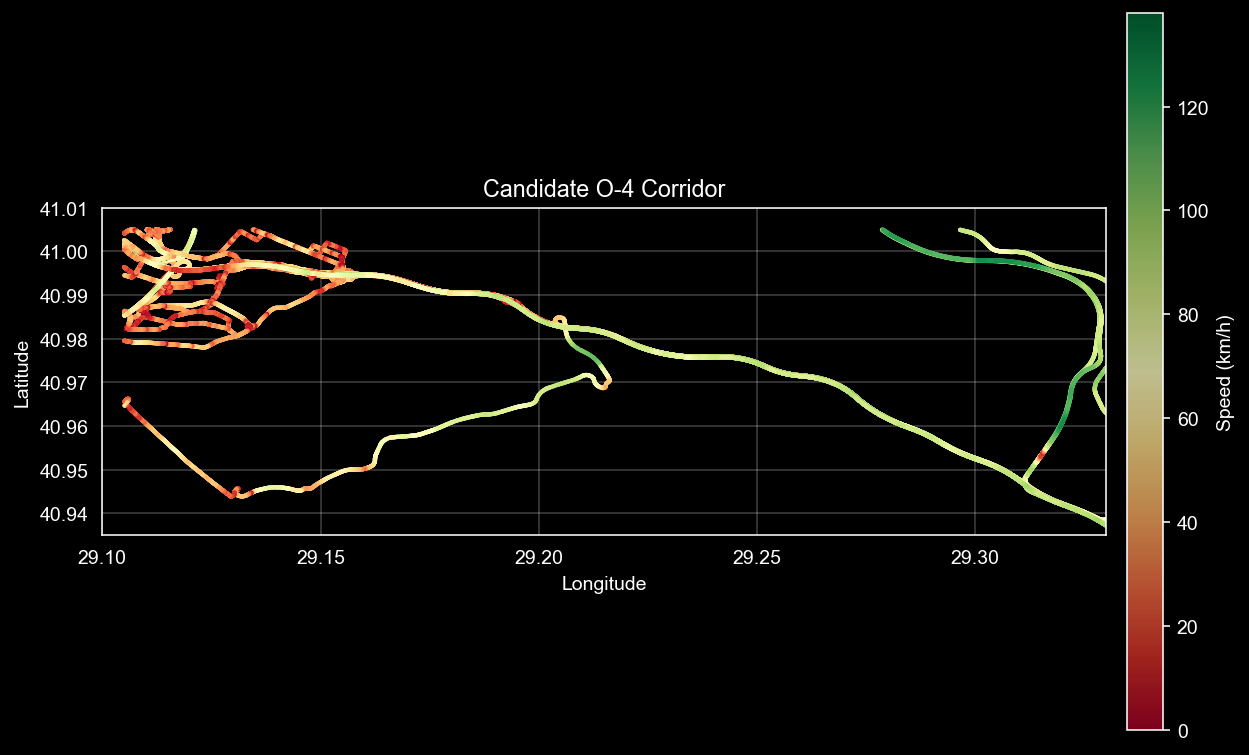

In [133]:
plot_route_points(
    data=df_candidate,
    title="Candidate O-4 Corridor",
    xlim=(29.10, 29.33),
    ylim=(40.935, 41.01),
    figsize=(9, 5.5),
    point_size=1.5,
    alpha=0.75
)

In [134]:
night_high_speed = df_candidate[
    (
            ((df_candidate["hour"] >= NIGHT_START_HOUR) | (df_candidate["hour"] < NIGHT_END_HOUR)) &
            (df_candidate["speed"] > CENTERLINE_SPEED_THRESHOLD)
    )
].copy()

print(f"Night high-speed data points: {len(night_high_speed):,}")

Night high-speed data points: 4,852


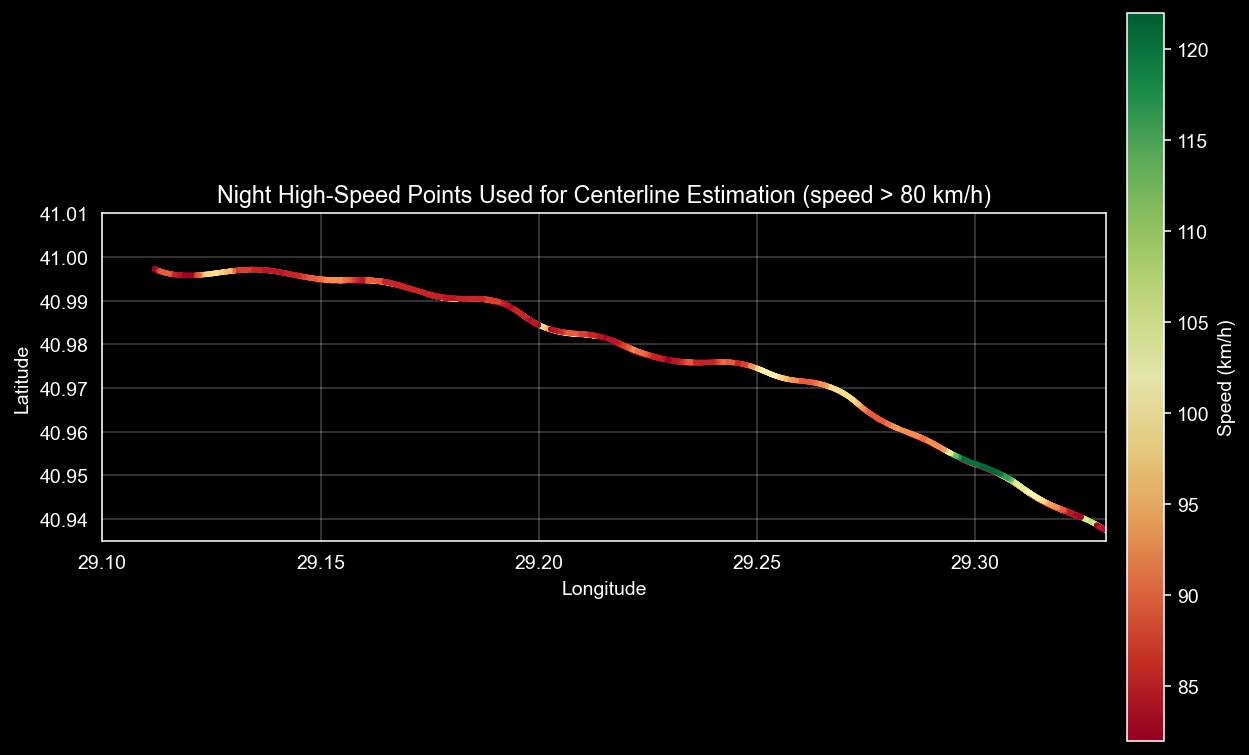

In [135]:
plot_route_points(
    data=night_high_speed,
    title=f"Night High-Speed Points Used for Centerline Estimation (speed > {CENTERLINE_SPEED_THRESHOLD} km/h)",
    xlim=(29.10, 29.33),
    ylim=(40.935, 41.01),
    figsize=(9, 5.5),
    point_size=3,
    alpha=0.9
)

In [136]:
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32635", always_xy=True)

x, y = to_utm.transform(
    night_high_speed["longitude"].to_numpy(),
    night_high_speed["latitude"].to_numpy()
)

night_high_speed["x"] = x
night_high_speed["y"] = y

coords_xy = night_high_speed[["x", "y"]].to_numpy()

mainline_clusterer = DBSCAN(
    eps=250,
    min_samples=30
)

night_high_speed["mainline_cluster"] = mainline_clusterer.fit_predict(coords_xy)

night_high_speed["mainline_cluster"].value_counts().sort_index()

mainline_cluster
0    4852
Name: count, dtype: int64

In [137]:
valid_clusters = night_high_speed[
    night_high_speed["mainline_cluster"] != -1
    ]["mainline_cluster"]

largest_cluster = valid_clusters.value_counts().idxmax()

mainline_points = night_high_speed[
    night_high_speed["mainline_cluster"] == largest_cluster
    ].copy()

print(f"Mainline reference points: {len(mainline_points):,}")

Mainline reference points: 4,852


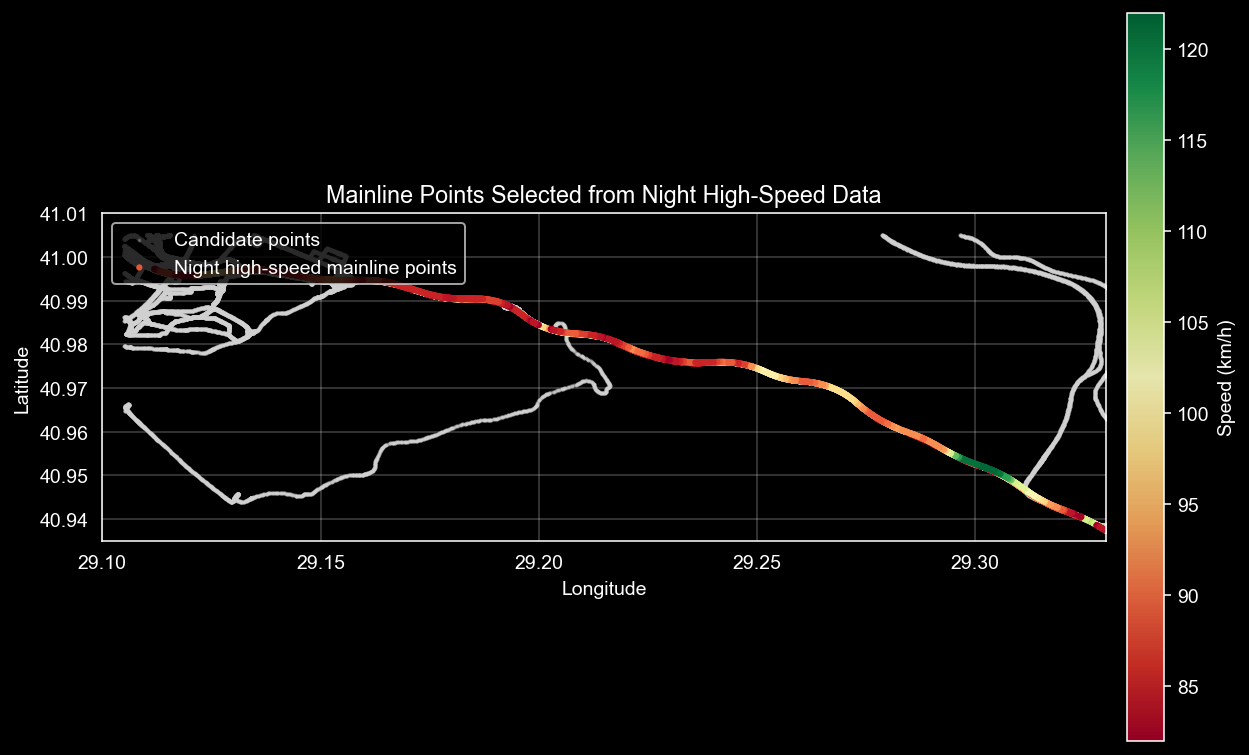

In [138]:
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)

ax.scatter(
    df_candidate["longitude"],
    df_candidate["latitude"],
    c="lightgray",
    s=1,
    alpha=0.25,
    label="Candidate points"
)

scatter = ax.scatter(
    mainline_points["longitude"],
    mainline_points["latitude"],
    c=mainline_points["speed"],
    cmap="RdYlGn",
    s=5,
    alpha=0.9,
    label="Night high-speed mainline points"
)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Speed (km/h)")

ax.set_title("Mainline Points Selected from Night High-Speed Data", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(29.10, 29.33)
ax.set_ylim(40.935, 41.01)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", frameon=True)

fig.tight_layout()
plt.show()

In [139]:
BIN_WIDTH_LON = 0.002

mainline_points["lon_bin"] = (
                                     mainline_points["longitude"] / BIN_WIDTH_LON
                             ).round() * BIN_WIDTH_LON

centerline_df = (
    mainline_points
    .groupby("lon_bin")
    .agg(
        longitude=("longitude", "median"),
        latitude=("latitude", "median"),
        count=("speed", "count")
    )
    .reset_index()
)

centerline_df = centerline_df[centerline_df["count"] >= 10].copy()
centerline_df = centerline_df.sort_values("longitude").reset_index(drop=True)

print(f"Centerline waypoint count: {len(centerline_df):,}")
centerline_df

Centerline waypoint count: 112


,lon_bin,longitude,latitude,count
0,29.112,29.112326,40.997087,16
1,29.114,29.114018,40.996496,24
2,29.116,29.115974,40.996061,26
3,29.118,29.118027,40.995821,30
4,29.120,29.120058,40.995772,21
...,...,...,...,...
107,29.326,29.325753,40.939707,21
108,29.328,29.328275,40.938328,43
109,29.330,29.329750,40.937478,33
110,29.332,29.331974,40.936208,21


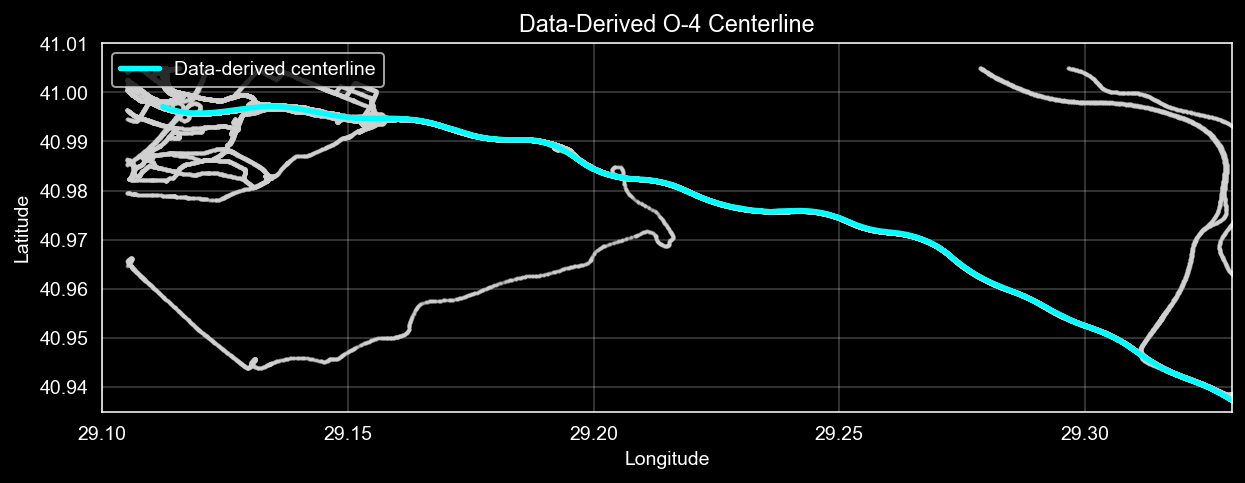

In [140]:
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)

ax.scatter(
    df_candidate["longitude"],
    df_candidate["latitude"],
    c="lightgray",
    s=1,
    alpha=0.25
)

ax.plot(
    centerline_df["longitude"],
    centerline_df["latitude"],
    color="cyan",
    linewidth=2.8,
    label="Data-derived centerline"
)

ax.set_title("Data-Derived O-4 Centerline", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(29.10, 29.33)
ax.set_ylim(40.935, 41.01)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", frameon=True)

fig.tight_layout()
plt.show()

In [141]:
route_waypoints = list(
    zip(centerline_df["longitude"], centerline_df["latitude"])
)

route_xy = [to_utm.transform(lon, lat) for lon, lat in route_waypoints]
route_line = LineString(route_xy)

x_all, y_all = to_utm.transform(
    df_candidate["longitude"].to_numpy(),
    df_candidate["latitude"].to_numpy()
)

points_all = [Point(px, py) for px, py in zip(x_all, y_all)]

df_candidate["distance_to_centerline_m"] = [
    route_line.distance(point) for point in points_all
]

df_candidate["route_position_m"] = [
    route_line.project(point) for point in points_all
]

df_candidate["route_position_km"] = df_candidate["route_position_m"] / 1000

In [142]:
df_route = df_candidate[
    df_candidate["distance_to_centerline_m"] <= ROUTE_BUFFER_M
    ].copy()

print(f"Final filtered O-4 data points: {len(df_route):,}")
print(f"Date range: {df_route['date'].min()} to {df_route['date'].max()}")
print(f"Rows retained from candidate corridor: {len(df_route) / len(df_candidate):.2%}")

Final filtered O-4 data points: 193,944
Date range: 2026-03-12 06:16:43.132000 to 2026-05-04 07:08:32.484000
Rows retained from candidate corridor: 64.43%


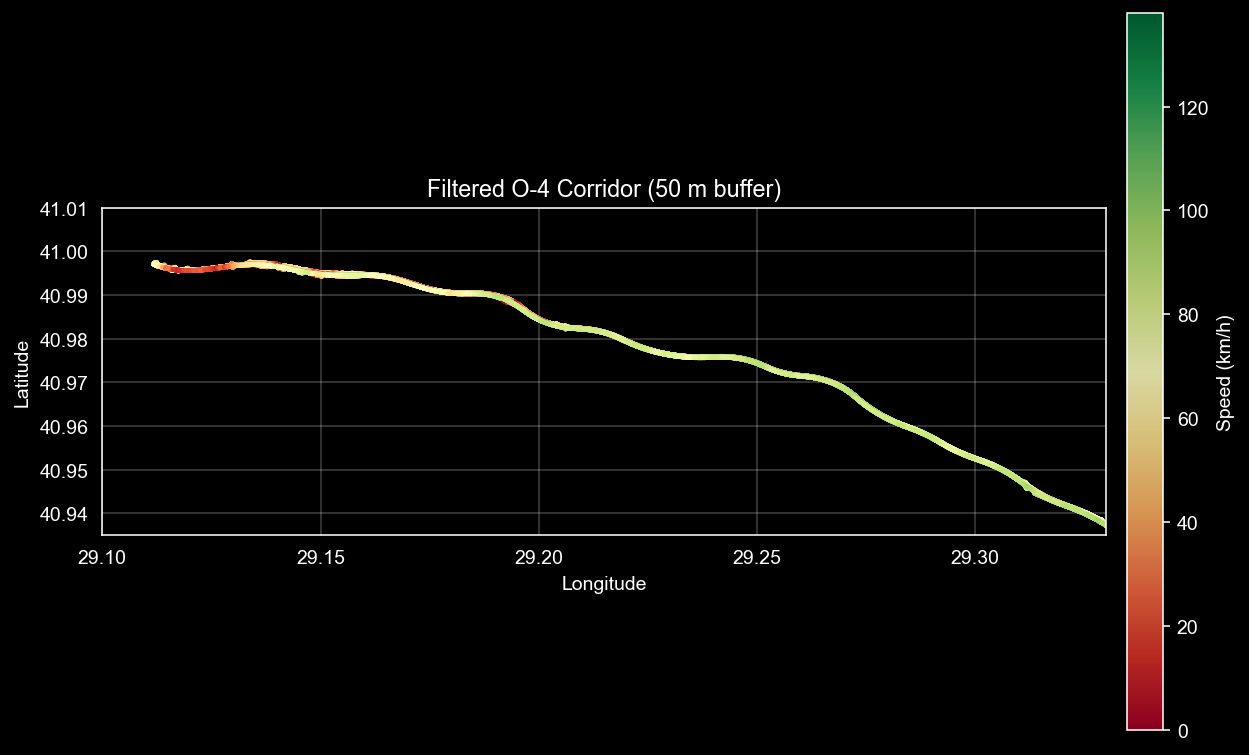

In [143]:
plot_route_points(
    data=df_route,
    title=f"Filtered O-4 Corridor ({ROUTE_BUFFER_M} m buffer)",
    centerline_df=None,
    xlim=(29.10, 29.33),
    ylim=(40.935, 41.01),
    figsize=(9, 5.5),
    point_size=2,
    alpha=0.85
)

In [144]:
df_route = df_route.sort_values("date").copy()

df_route["time_gap_sec"] = df_route["date"].diff().dt.total_seconds()
df_route["trip_group"] = (df_route["time_gap_sec"] > 600).cumsum()

print(f"Trip-like groups: {df_route['trip_group'].nunique():,}")

Trip-like groups: 73


In [145]:
trip_positions = (
    df_route
    .groupby("trip_group")
    .agg(
        start_pos=("route_position_km", "first"),
        end_pos=("route_position_km", "last"),
        point_count=("route_position_km", "count")
    )
)

trip_positions["displacement_km"] = (
        trip_positions["end_pos"] - trip_positions["start_pos"]
)

trip_positions["direction"] = "Undetermined"

trip_positions.loc[
    trip_positions["displacement_km"] > 1.0,
    "direction"
] = "Eastbound"

trip_positions.loc[
    trip_positions["displacement_km"] < -1.0,
    "direction"
] = "Westbound"

df_route = df_route.merge(
    trip_positions[["direction"]],
    left_on="trip_group",
    right_index=True,
    how="left"
)

df_route["direction"].value_counts()

direction
Westbound       102953
Eastbound        90175
Undetermined       816
Name: count, dtype: int64

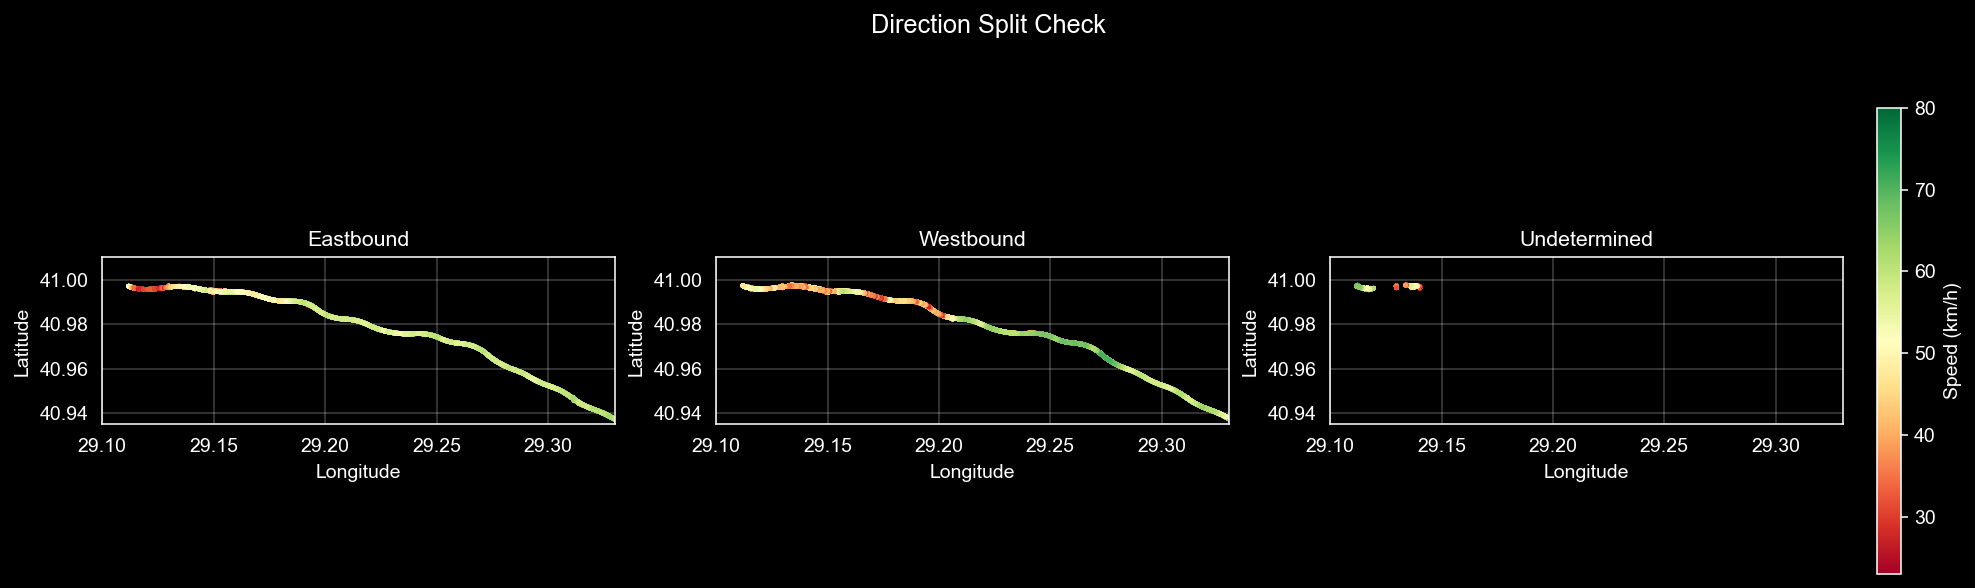

In [146]:
directions = ["Eastbound", "Westbound", "Undetermined"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
    dpi=140,
    constrained_layout=True
)

for ax, direction in zip(axes, directions):
    subset = df_route[df_route["direction"] == direction]

    scatter = ax.scatter(
        subset["longitude"],
        subset["latitude"],
        c=subset["speed"],
        cmap="RdYlGn",
        s=2
    )

    ax.set_title(direction, fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(29.10, 29.33)
    ax.set_ylim(40.935, 41.01)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

fig.colorbar(
    scatter,
    ax=axes,
    location="right",
    shrink=0.8,
    pad=0.02,
    label="Speed (km/h)"
)

fig.suptitle("Direction Split Check", fontsize=13)
plt.show()

In [147]:
df_route_directed = df_route[
    df_route["direction"] != "Undetermined"
    ].copy()

df_route_directed["direction"].value_counts()

direction
Westbound    102953
Eastbound     90175
Name: count, dtype: int64

In [148]:
def assign_window(row):
    minutes = row["hour"] * 60 + row["minute"]

    if 6 * 60 <= minutes < 10 * 60 + 30:
        return "Morning Peak"
    elif 10 * 60 + 30 <= minutes < 14 * 60 + 30:
        return "Midday"
    elif 15 * 60 <= minutes < 20 * 60:
        return "Evening Peak"
    else:
        return None

In [149]:
df_time = df_route.copy()

df_time["time_window"] = df_time.apply(assign_window, axis=1)
df_time = df_time[df_time["time_window"].notna()].copy()

df_time["is_slow"] = df_time["speed"] < SLOW_THRESHOLD

print(f"Analysis-ready data points: {len(df_time):,}")

Analysis-ready data points: 170,695


In [150]:
window_order = ["Morning Peak", "Midday", "Evening Peak"]

time_summary = (
    df_time
    .groupby("time_window")["speed"]
    .agg(["count", "mean", "median", "std"])
    .reindex(window_order)
)

time_summary

,count,mean,median,std
time_window,,,,
Morning Peak,60724,67.157911,77.0,32.389898
Midday,57009,55.312933,56.0,30.656572
Evening Peak,52962,53.791624,53.0,31.159645


In [151]:
slow_share = (
    df_time
    .groupby("time_window")["is_slow"]
    .mean()
    .reindex(window_order)
)

slow_share

time_window
Morning Peak    0.276810
Midday          0.402112
Evening Peak    0.427608
Name: is_slow, dtype: float64

In [152]:
direction_summary = (
    df_route_directed
    .groupby("direction")["speed"]
    .agg(["count", "mean", "median", "std"])
)

direction_summary

,count,mean,median,std
direction,,,,
Eastbound,90175,65.780793,76.0,32.181741
Westbound,102953,53.264596,51.0,30.334905


In [153]:
direction_time_summary = (
    df_time[df_time["direction"] != "Undetermined"]
    .groupby(["direction", "time_window"])["speed"]
    .agg(["count", "mean", "median", "std"])
)

direction_time_summary

count       mean  median        std
direction time_window                                      
Eastbound Midday        20048  69.931265    79.0  30.434911
          Morning Peak  59197  66.713904    77.0  32.641243
Westbound Evening Peak  52579  53.836950    53.0  31.249331
          Midday        36528  47.311870    43.0  27.861230
          Morning Peak   1527  84.370661    85.0  10.564729

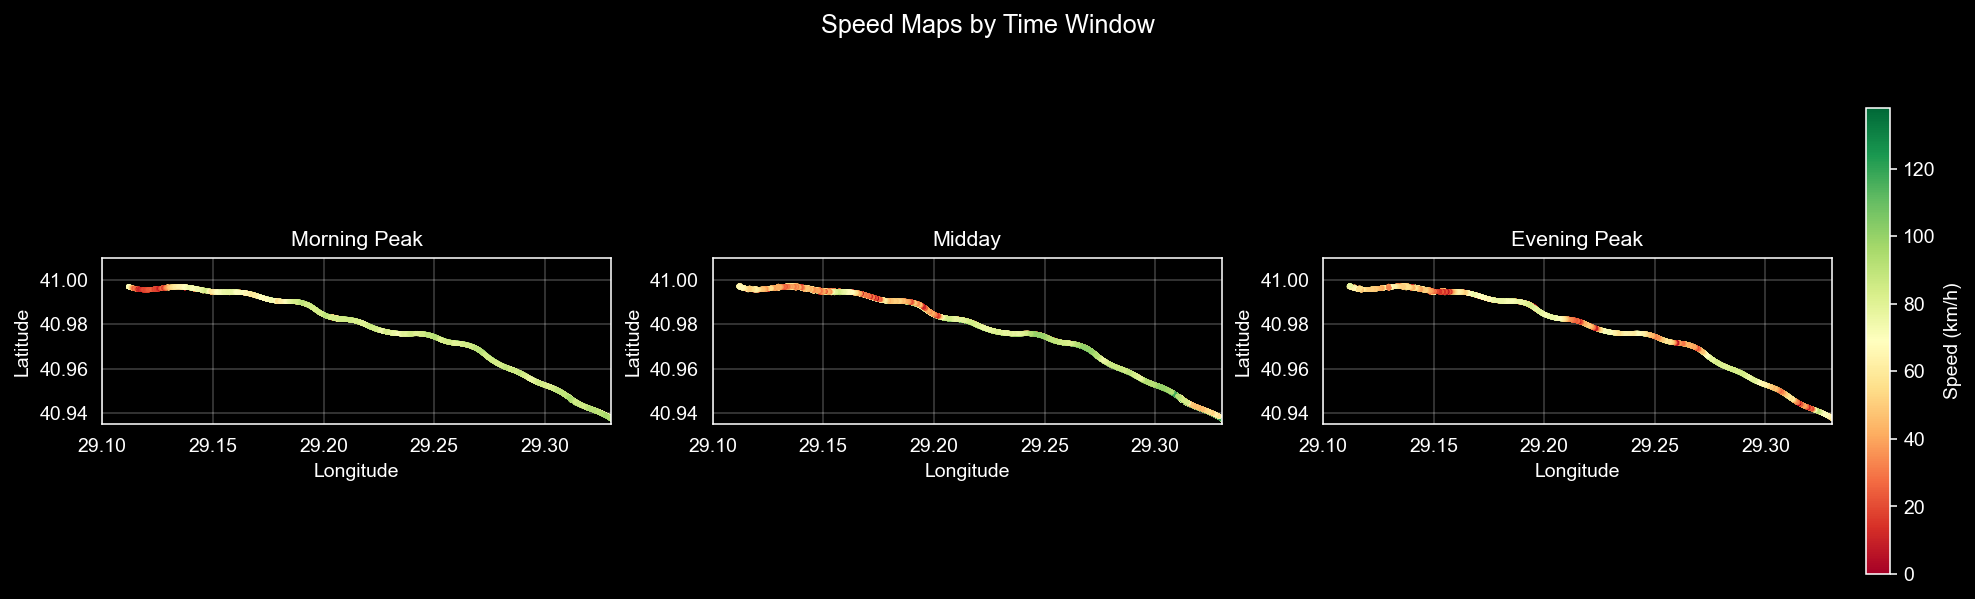

In [154]:
vmin = df_time["speed"].min()
vmax = df_time["speed"].max()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
    dpi=140,
    constrained_layout=True
)

for ax, window in zip(axes, window_order):
    subset = df_time[df_time["time_window"] == window]

    scatter = ax.scatter(
        subset["longitude"],
        subset["latitude"],
        c=subset["speed"],
        cmap="RdYlGn",
        s=2,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(window, fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(29.10, 29.33)
    ax.set_ylim(40.935, 41.01)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

fig.colorbar(
    scatter,
    ax=axes,
    location="right",
    shrink=0.8,
    pad=0.02,
    label="Speed (km/h)"
)

fig.suptitle("Speed Maps by Time Window", fontsize=13)
plt.show()

In [155]:
morning_speed = df_time[df_time["time_window"] == "Morning Peak"]["speed"]
midday_speed = df_time[df_time["time_window"] == "Midday"]["speed"]
evening_speed = df_time[df_time["time_window"] == "Evening Peak"]["speed"]

anova_stat, anova_p = f_oneway(
    morning_speed,
    midday_speed,
    evening_speed
)

anova_result = pd.DataFrame({
    "test": ["One-way ANOVA"],
    "hypothesis": ["Mean speed differs across time windows"],
    "statistic": [anova_stat],
    "p_value": [anova_p]
})

anova_result

,test,hypothesis,statistic,p_value
0,One-way ANOVA,Mean speed differs across time windows,3163.089052,0.0


In [166]:
contingency_table = (
    pd.crosstab(df_time["time_window"], df_time["is_slow"])
    .reindex(window_order)
    .fillna(0)
    .astype(int)
)

chi_stat, chi_p, chi_dof, chi_expected = chi2_contingency(contingency_table)

chi_result = pd.DataFrame({
    "test": ["Chi-square test"],
    "hypothesis": ["Slow-point proportion differs across time windows"],
    "statistic": [chi_stat],
    "p_value": [chi_p],
    "degrees_of_freedom": [chi_dof]
})

chi_result

,test,hypothesis,statistic,p_value,degrees_of_freedom
0,Chi-square test,Slow-point proportion differs across time windows,3270.296072,0.0,2


In [167]:
contingency_table

is_slow,False,True
time_window,,
Morning Peak,43915,16809
Midday,34085,22924
Evening Peak,30315,22647


In [158]:
def pairwise_ttests(df):
    groups = {
        "Morning Peak": df[df["time_window"] == "Morning Peak"]["speed"],
        "Midday": df[df["time_window"] == "Midday"]["speed"],
        "Evening Peak": df[df["time_window"] == "Evening Peak"]["speed"]
    }

    pairs = [
        ("Morning Peak", "Midday"),
        ("Morning Peak", "Evening Peak"),
        ("Midday", "Evening Peak")
    ]

    rows = []

    for first, second in pairs:
        stat, p_value = ttest_ind(
            groups[first],
            groups[second],
            equal_var=False
        )

        rows.append({
            "comparison": f"{first} vs {second}",
            "t_statistic": stat,
            "p_value": p_value
        })

    return pd.DataFrame(rows)


pairwise_results = pairwise_ttests(df_time)
pairwise_results

,comparison,t_statistic,p_value
0,Morning Peak vs Midday,64.464261,0.000000e+00
1,Morning Peak vs Evening Peak,70.832152,0.000000e+00
2,Midday vs Evening Peak,8.152961,3.588406e-16


In [159]:
slow_points = df_time[
    df_time["speed"] < SLOW_THRESHOLD
    ].copy()

print(f"Slow points used for DBSCAN: {len(slow_points):,}")

Slow points used for DBSCAN: 62,380


In [160]:
eps_radians = EPS_METERS / EARTH_RADIUS_M

coords_rad = np.radians(
    slow_points[["latitude", "longitude"]].to_numpy()
)

dbscan = DBSCAN(
    eps=eps_radians,
    min_samples=MIN_SAMPLES,
    metric="haversine"
)

slow_points["cluster"] = dbscan.fit_predict(coords_rad)

slow_points["cluster"].value_counts().sort_index()

cluster
-1        9
 0    54931
 1      419
 2      254
 3     3833
 4      175
 5      474
 6     2285
Name: count, dtype: int64

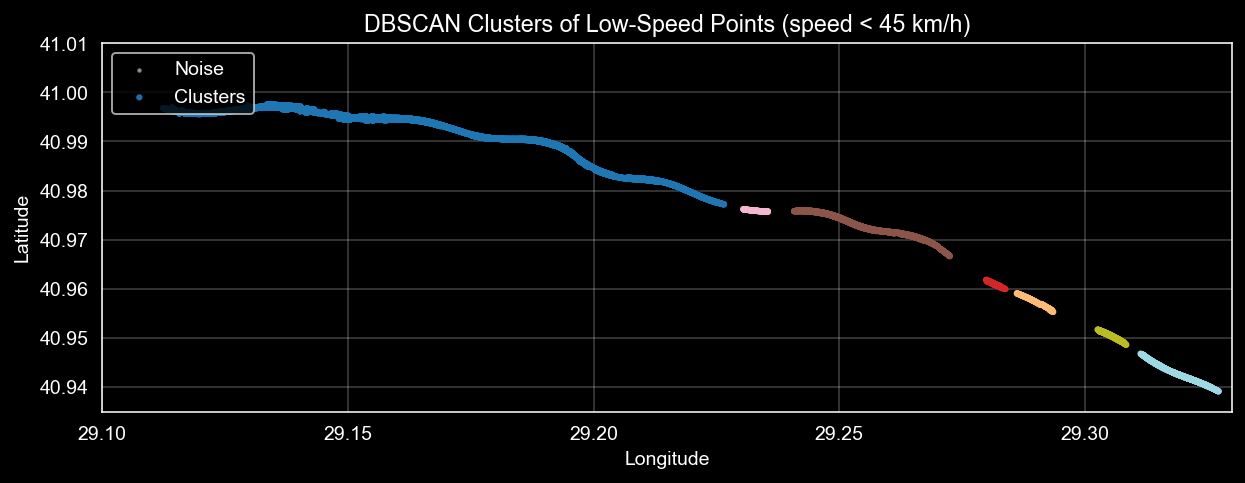

In [161]:
clustered = slow_points[slow_points["cluster"] != -1]
noise = slow_points[slow_points["cluster"] == -1]

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)

ax.scatter(
    noise["longitude"],
    noise["latitude"],
    c="lightgray",
    s=2,
    alpha=0.5,
    label="Noise"
)

ax.scatter(
    clustered["longitude"],
    clustered["latitude"],
    c=clustered["cluster"],
    cmap="tab20",
    s=5,
    alpha=0.9,
    label="Clusters"
)

ax.set_title(
    f"DBSCAN Clusters of Low-Speed Points (speed < {SLOW_THRESHOLD} km/h)",
    fontsize=12
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(29.10, 29.33)
ax.set_ylim(40.935, 41.01)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", frameon=True)

fig.tight_layout()
plt.show()

In [162]:
cluster_summary = (
    slow_points[slow_points["cluster"] != -1]
    .groupby("cluster")
    .agg(
        point_count=("speed", "count"),
        mean_speed=("speed", "mean"),
        median_speed=("speed", "median"),
        min_speed=("speed", "min"),
        center_lat=("latitude", "mean"),
        center_lon=("longitude", "mean"),
        dominant_time_window=("time_window", lambda x: x.value_counts().idxmax()),
        dominant_direction=("direction", lambda x: x.value_counts().idxmax())
    )
    .sort_values("point_count", ascending=False)
)

cluster_summary

,point_count,mean_speed,median_speed,min_speed,center_lat,center_lon,dominant_time_window,dominant_direction
cluster,,,,,,,,
0,54931,21.700169,19.0,0,40.992737,29.159584,Midday,Westbound
3,3833,28.574485,29.0,0,40.972780,29.255418,Midday,Westbound
6,2285,24.355799,24.0,0,40.942933,29.318606,Evening Peak,Westbound
5,474,34.881857,35.0,16,40.950346,29.305487,Evening Peak,Westbound
1,419,24.081146,23.0,5,40.957220,29.290210,Morning Peak,Eastbound
2,254,38.602362,40.0,31,40.960920,29.281759,Morning Peak,Westbound
4,175,31.125714,35.0,11,40.975930,29.232862,Morning Peak,Eastbound


In [163]:
def run_dbscan_for_threshold(df, threshold, eps_meters=EPS_METERS, min_samples=MIN_SAMPLES):
    points = df[df["speed"] < threshold].copy()

    if len(points) == 0:
        return points, pd.DataFrame()

    eps_radians = eps_meters / EARTH_RADIUS_M

    coords_rad = np.radians(
        points[["latitude", "longitude"]].to_numpy()
    )

    model = DBSCAN(
        eps=eps_radians,
        min_samples=min_samples,
        metric="haversine"
    )

    points["cluster"] = model.fit_predict(coords_rad)

    summary = (
        points[points["cluster"] != -1]
        .groupby("cluster")
        .agg(
            point_count=("speed", "count"),
            mean_speed=("speed", "mean"),
            median_speed=("speed", "median"),
            center_lat=("latitude", "mean"),
            center_lon=("longitude", "mean"),
            dominant_time_window=("time_window", lambda x: x.value_counts().idxmax()),
            dominant_direction=("direction", lambda x: x.value_counts().idxmax())
        )
        .sort_values("point_count", ascending=False)
    )

    return points, summary

In [164]:
threshold_results = []

for threshold in [40, 45, 50]:
    threshold_points, threshold_summary = run_dbscan_for_threshold(
        df_time,
        threshold
    )

    if "cluster" in threshold_points.columns:
        num_clusters = threshold_points[
            threshold_points["cluster"] != -1
            ]["cluster"].nunique()

        num_noise = (threshold_points["cluster"] == -1).sum()
    else:
        num_clusters = 0
        num_noise = 0

    threshold_results.append({
        "threshold": threshold,
        "slow_points": len(threshold_points),
        "clusters": num_clusters,
        "noise_points": num_noise
    })

threshold_sensitivity = pd.DataFrame(threshold_results)
threshold_sensitivity

,threshold,slow_points,clusters,noise_points
0,40,56573,7,0
1,45,62380,7,9
2,50,68067,7,37
